# CE322 Pattern Recognition — TikTok Project
## Notebook 3: Supervised Learning — Classification

This notebook trains and compares five pattern recognition models (Logistic Regression, Naive Bayes, K-NN, SVM, Decision Tree) to classify TikTok videos into Low / Medium / High engagement classes.

In [2]:
# Install required packages (run this cell first if you get ModuleNotFoundError)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy'],
    stdout=subprocess.DEVNULL)
print('All packages ready!')

All packages ready!



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text

df = pd.read_csv('../data/tiktok_features.csv')
with open('../data/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)

# Drop rows with any NaN in feature cols or target
df_model = df[FEATURE_COLS + ['performance_label']].dropna()
X = df_model[FEATURE_COLS].values
y = df_model['performance_label'].values

print(f"Dataset for modeling: {X.shape}")
print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")

Dataset for modeling: (49459, 30)
Class distribution: {2: 16923, 0: 16417, 1: 16119}


## 3.1 Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]}")
print(f"Test  size: {X_test.shape[0]}")

Train size: 39567
Test  size: 9892


## 3.2 Model Definitions

All models are wrapped in a `Pipeline` with `StandardScaler` to ensure fair comparison.

In [5]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GaussianNB())
    ]),
    'K-NN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42))
    ]),
}
print("Models defined:", list(models.keys()))

Models defined: ['Logistic Regression', 'Naive Bayes', 'K-NN (k=7)', 'SVM (RBF)', 'Decision Tree']


## 3.3 Cross-Validation (5-Fold Stratified)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=['accuracy', 'f1_macro'],
                            return_train_score=False, n_jobs=-1)
    cv_results[name] = {
        'CV Accuracy (mean)': scores['test_accuracy'].mean(),
        'CV Accuracy (std)':  scores['test_accuracy'].std(),
        'CV F1-macro (mean)': scores['test_f1_macro'].mean(),
        'CV F1-macro (std)':  scores['test_f1_macro'].std(),
    }
    print(f"{name}: Acc={scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}  |  F1={scores['test_f1_macro'].mean():.4f}")

cv_df = pd.DataFrame(cv_results).T
cv_df.to_csv('../data/cv_results.csv')
cv_df

Logistic Regression: Acc=0.9412 ± 0.0022  |  F1=0.9409
Naive Bayes: Acc=0.6517 ± 0.0242  |  F1=0.6400
K-NN (k=7): Acc=0.8465 ± 0.0032  |  F1=0.8463
SVM (RBF): Acc=0.9575 ± 0.0013  |  F1=0.9573
Decision Tree: Acc=0.9830 ± 0.0012  |  F1=0.9829


,CV Accuracy (mean),CV Accuracy (std),CV F1-macro (mean),CV F1-macro (std)
Logistic Regression,0.941188,0.002155,0.940880,0.002091
Naive Bayes,0.651704,0.024189,0.640003,0.030581
K-NN (k=7),0.846514,0.003174,0.846288,0.003102
SVM (RBF),0.957465,0.001349,0.957277,0.001317
Decision Tree,0.982966,0.001242,0.982882,0.001236


## 3.4 Test Set Evaluation


  Logistic Regression
              precision    recall  f1-score   support

         Low       0.96      0.96      0.96      3283
      Medium       0.92      0.92      0.92      3224
        High       0.97      0.96      0.96      3385

    accuracy                           0.95      9892
   macro avg       0.95      0.95      0.95      9892
weighted avg       0.95      0.95      0.95      9892


  Naive Bayes
              precision    recall  f1-score   support

         Low       0.95      0.31      0.47      3283
      Medium       0.48      0.93      0.63      3224
        High       0.93      0.71      0.80      3385

    accuracy                           0.65      9892
   macro avg       0.79      0.65      0.63      9892
weighted avg       0.79      0.65      0.64      9892


  K-NN (k=7)
              precision    recall  f1-score   support

         Low       0.90      0.90      0.90      3283
      Medium       0.77      0.79      0.78      3224
        High       0.89

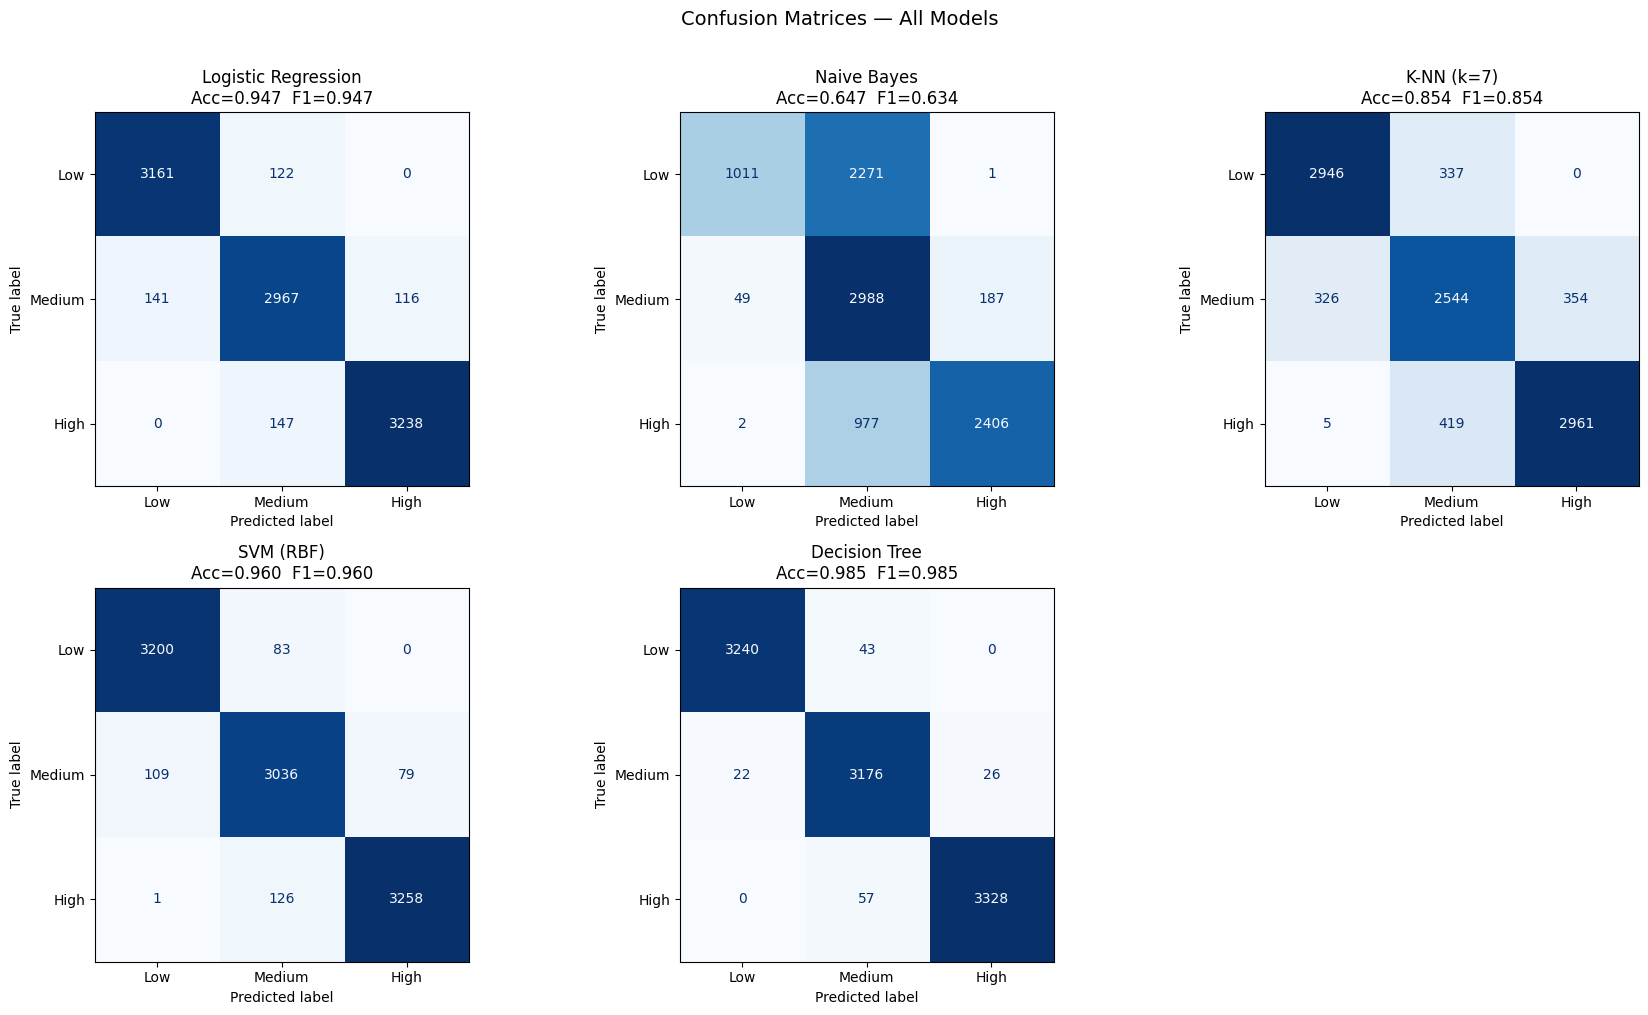

In [7]:
test_results = {}
class_names = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, pipe) in enumerate(models.items()):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    test_results[name] = {'Test Accuracy': acc, 'Test F1-macro': f1}

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAcc={acc:.3f}  F1={f1:.3f}')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

test_df = pd.DataFrame(test_results).T
test_df.to_csv('../data/test_results.csv')

## 3.5 Model Comparison Summary

                     CV Accuracy (mean)  CV F1-macro (mean)  Test Accuracy  Test F1-macro
Decision Tree                    0.9830              0.9829         0.9850         0.9850
SVM (RBF)                        0.9575              0.9573         0.9598         0.9596
Logistic Regression              0.9412              0.9409         0.9468         0.9465
K-NN (k=7)                       0.8465              0.8463         0.8543         0.8540
Naive Bayes                      0.6517              0.6400         0.6475         0.6340


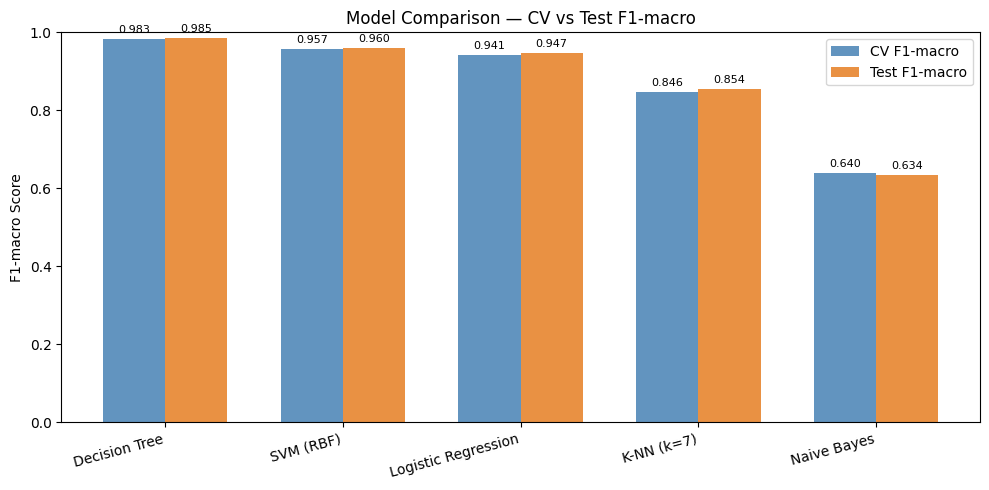

In [8]:
summary = cv_df[['CV Accuracy (mean)', 'CV F1-macro (mean)']].copy()
summary['Test Accuracy'] = test_df['Test Accuracy']
summary['Test F1-macro'] = test_df['Test F1-macro']
summary = summary.round(4).sort_values('Test F1-macro', ascending=False)
print(summary.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
width = 0.35
bars1 = ax.bar(x - width/2, summary['CV F1-macro (mean)'], width, label='CV F1-macro', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, summary['Test F1-macro'],       width, label='Test F1-macro', color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('F1-macro Score')
ax.set_title('Model Comparison — CV vs Test F1-macro')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

## 3.6 Decision Tree — Feature Importance

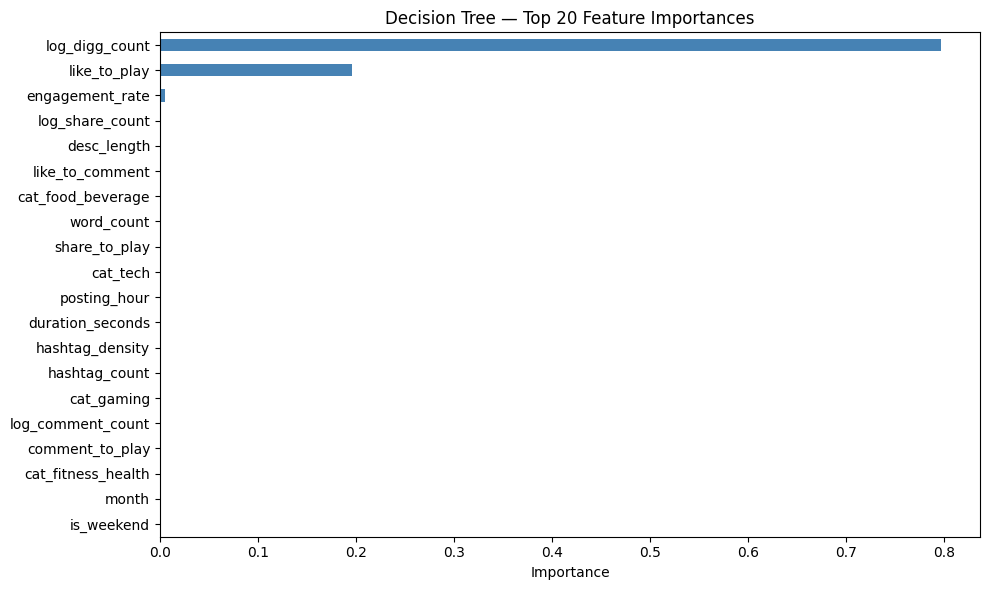

Top 10 features:
log_digg_count       0.797184
like_to_play         0.196340
engagement_rate      0.004800
log_share_count      0.000320
desc_length          0.000293
like_to_comment      0.000221
cat_food_beverage    0.000147
word_count           0.000139
share_to_play        0.000131
cat_tech             0.000102


In [9]:
dt_clf = models['Decision Tree'].named_steps['clf']
importances = pd.Series(dt_clf.feature_importances_, index=FEATURE_COLS)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Decision Tree — Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print("Top 10 features:")
print(top20.head(10).to_string())